In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from src.fluid import Fluid
from src.reservoir import ResProps, Reservoir
from src.pipe import Pipe
from src.well import Well
from src.compressor import DCS
from src.simulator import FieldSimulator

# Исходные данные
M_gas = 0.01969
rho_c_gas = 0.6799
xa_gas = 0.0206
xy_gas = 0.009699
T_res = 310.0

fluid = Fluid(M=M_gas, rho_c=rho_c_gas, xa=xa_gas, xy=xy_gas, T=T_res)

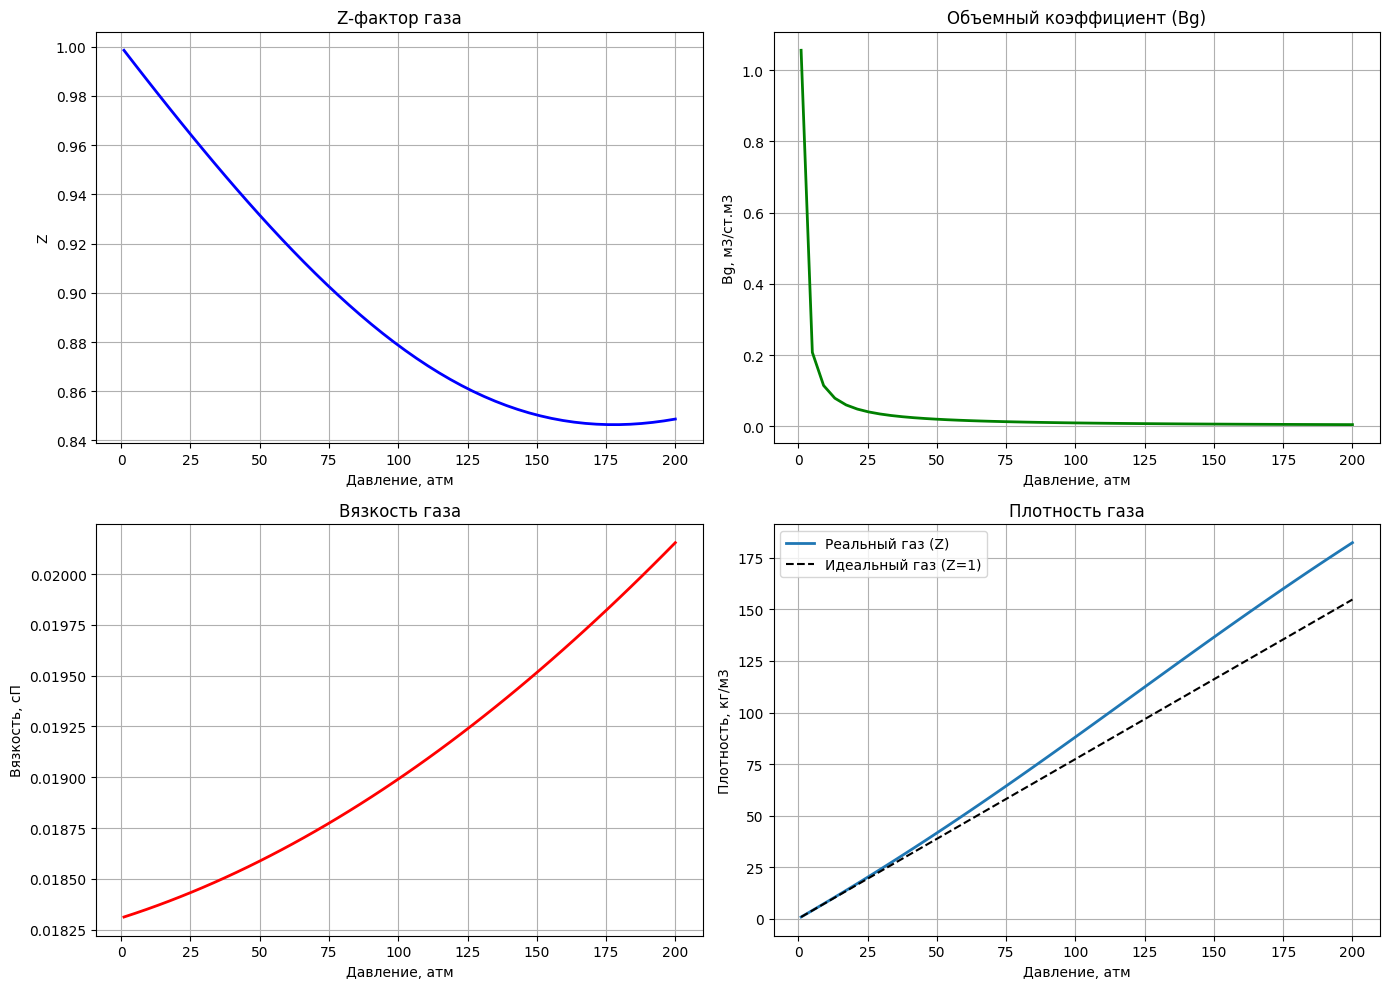

In [2]:
# Диапазон давлений от 1 до 200 атм
P_range = np.linspace(1, 200, 50)

Z_vals = [fluid.z(p) for p in P_range]
Bg_vals = [fluid.bg(p) for p in P_range]
mu_vals = [fluid.mu(p) for p in P_range]

# Сравнение плотностей
rho_real = [fluid.ro(p) for p in P_range]
# Плотность идеального газа (уравнение состояния при Z=1)
rho_ideal = [(p * 101325 * fluid.M) / (1.0 * 8.314 * fluid.T) for p in P_range]

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(P_range, Z_vals, color='blue', linewidth=2)
axs[0, 0].set_title('Z-фактор газа')
axs[0, 0].set_xlabel('Давление, атм')
axs[0, 0].set_ylabel('Z')
axs[0, 0].grid(True)

axs[0, 1].plot(P_range, Bg_vals, color='green', linewidth=2)
axs[0, 1].set_title('Объемный коэффициент (Bg)')
axs[0, 1].set_xlabel('Давление, атм')
axs[0, 1].set_ylabel('Bg, м3/ст.м3')
axs[0, 1].grid(True)

axs[1, 0].plot(P_range, mu_vals, color='red', linewidth=2)
axs[1, 0].set_title('Вязкость газа')
axs[1, 0].set_xlabel('Давление, атм')
axs[1, 0].set_ylabel('Вязкость, сП')
axs[1, 0].grid(True)

axs[1, 1].plot(P_range, rho_real, label='Реальный газ (Z)', linewidth=2)
axs[1, 1].plot(P_range, rho_ideal, label='Идеальный газ (Z=1)', linestyle='--', color='black')
axs[1, 1].set_title('Плотность газа')
axs[1, 1].set_xlabel('Давление, атм')
axs[1, 1].set_ylabel('Плотность, кг/м3')
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

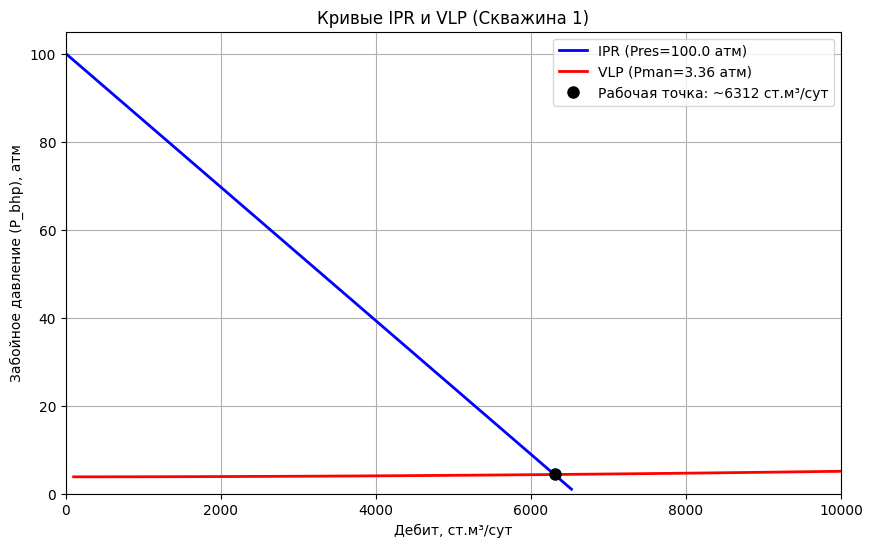

In [3]:
# Инициализация скважины 1
pipe1 = Pipe(L=2000, D=0.062, roughness=0.000046, fluid=fluid, vertical_depth=1800)
well1 = Well(fluid=fluid, k=50, h=25, re=500, rw=0.1, pipe=pipe1)

P_res = 100.0
P_man = 3.36  

# Расчет IPR
P_bhp_range = np.linspace(1, P_res, 50)
q_ipr = [well1.q(P_res, p) for p in P_bhp_range]

# Расчет VLP (берем диапазон дебитов от 100 до 10000)
q_vlp_range = np.linspace(100, 10000, 50)
P_bhp_vlp = [P_man + well1.pipe.dp(P_man, q).dP for q in q_vlp_range]

plt.figure(figsize=(10, 6))
plt.plot(q_ipr, P_bhp_range, label=f'IPR (Pres={P_res} атм)', color='blue', linewidth=2)
plt.plot(q_vlp_range, P_bhp_vlp, label=f'VLP (Pman={P_man} атм)', color='red', linewidth=2)

# Отметка рабочей точки (приблизительное пересечение из нашего симулятора)
q_op = 6312.0
P_bhp_op = P_man + well1.pipe.dp(P_man, q_op).dP
plt.plot(q_op, P_bhp_op, 'ko', markersize=8, label=f'Рабочая точка: ~{q_op:.0f} ст.м³/сут')

plt.title('Кривые IPR и VLP (Скважина 1)')
plt.xlabel('Дебит, ст.м³/сут')
plt.ylabel('Забойное давление (P_bhp), атм')
plt.xlim(0, 10000)
plt.ylim(0, 105)
plt.grid(True)
plt.legend()
plt.show()

День   0: P_res = 100.00 атм, q_total = 18922.0 ст.м³/сут, Gp = 18.9 тыс.м³
День  30: P_res = 100.00 атм, q_total = 18922.0 ст.м³/сут, Gp = 586.6 тыс.м³
День  60: P_res = 100.00 атм, q_total = 18921.9 ст.м³/сут, Gp = 1154.2 тыс.м³
День  90: P_res = 100.00 атм, q_total = 18921.9 ст.м³/сут, Gp = 1721.9 тыс.м³
День 120: P_res = 100.00 атм, q_total = 18921.9 ст.м³/сут, Gp = 2289.6 тыс.м³
День 150: P_res = 100.00 атм, q_total = 18921.8 ст.м³/сут, Gp = 2857.2 тыс.м³
День 179: P_res = 100.00 атм, q_total = 18921.8 ст.м³/сут, Gp = 3405.9 тыс.м³


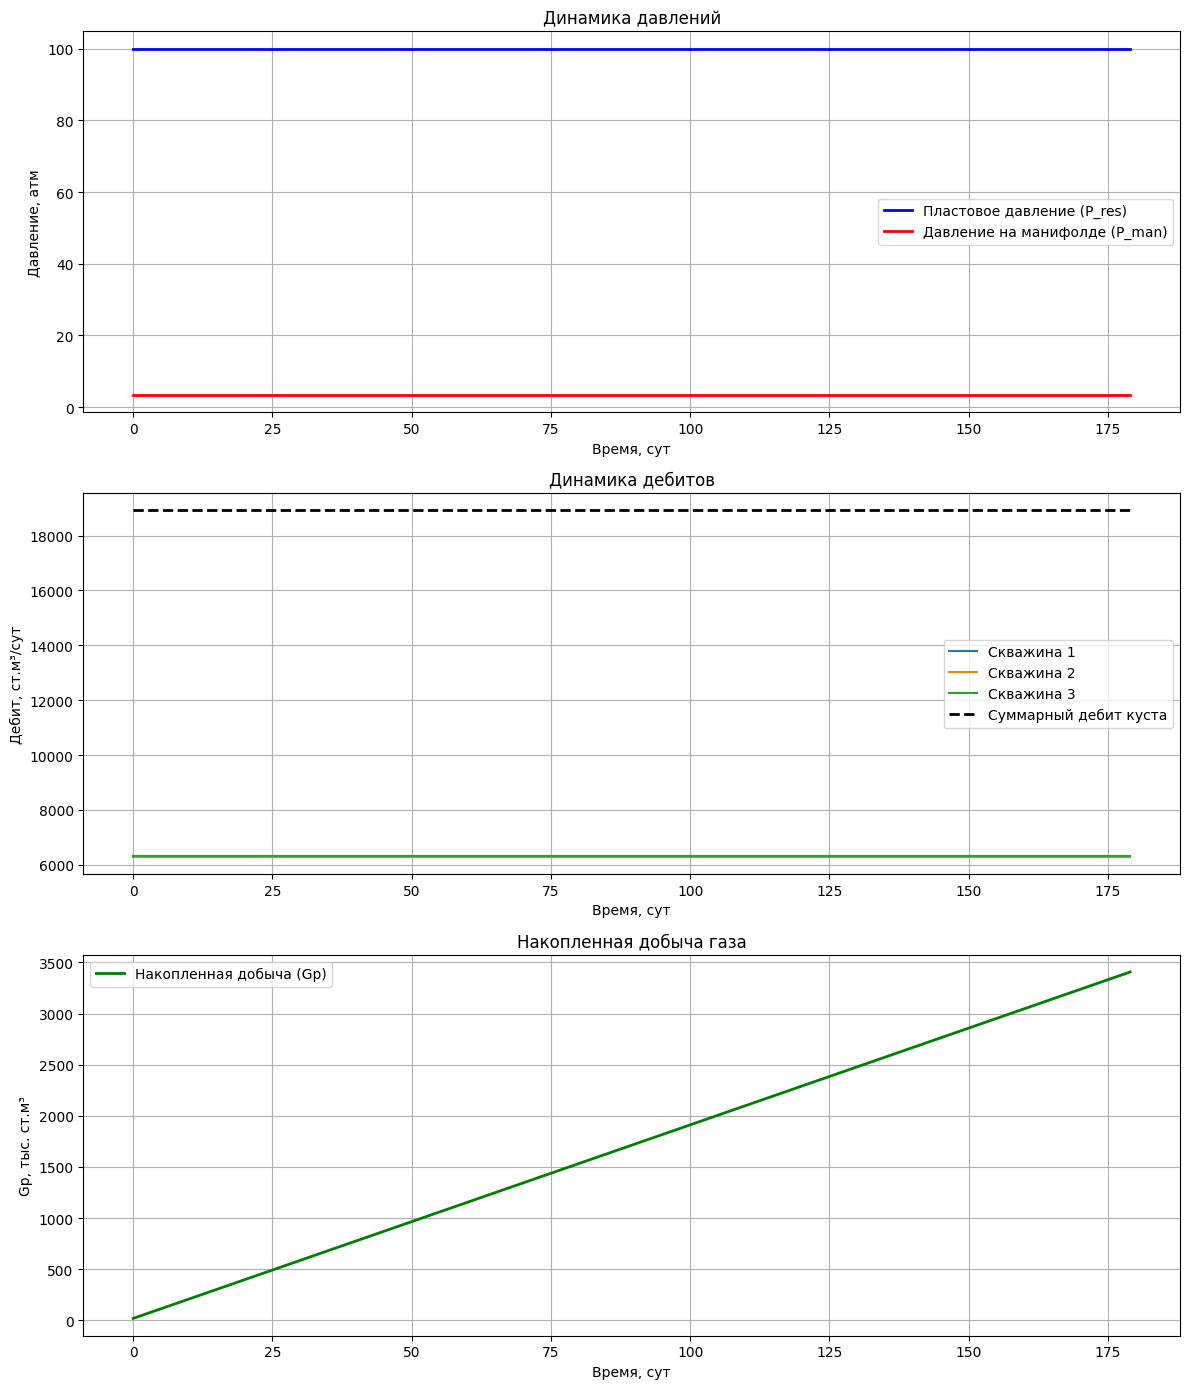

In [4]:
# Заново создаем объекты, чтобы сбросить состояние пласта до начального
V_res = math.pi * (500**2) * 25
reservoir_dyn = Reservoir(ResProps(P=100.0, V=V_res, T=T_res), fluid)

pipe1 = Pipe(L=2000, D=0.062, roughness=0.000046, fluid=fluid, vertical_depth=1800)
well1 = Well(fluid, k=50, h=25, re=500, rw=0.1, pipe=pipe1)

pipe2 = Pipe(L=2500, D=0.062, roughness=0.000046, fluid=fluid, vertical_depth=1900)
well2 = Well(fluid, k=50, h=25, re=500, rw=0.1, pipe=pipe2)

pipe3 = Pipe(L=1800, D=0.073, roughness=0.000046, fluid=fluid, vertical_depth=1600)
well3 = Well(fluid, k=50, h=25, re=500, rw=0.1, pipe=pipe3)

shlyf = Pipe(L=5000, D=0.200, roughness=0.000046, fluid=fluid, vertical_depth=0.0, name="shlyf")
dcs_dyn = DCS(CR=1.5, P_line=5.0, q_ext=500.0)

# Запуск
simulator_dyn = FieldSimulator(reservoir_dyn, [well1, well2, well3], shlyf, dcs_dyn)
df_dyn = simulator_dyn.run(N_days=180, dt=1.0)

# Построение графиков
fig, axs = plt.subplots(3, 1, figsize=(12, 14))

# 1. Давления
axs[0].plot(df_dyn['t'], df_dyn['P_res'], label='Пластовое давление (P_res)', color='blue', linewidth=2)
axs[0].plot(df_dyn['t'], df_dyn['P_man'], label='Давление на манифолде (P_man)', color='red', linewidth=2)
axs[0].set_title('Динамика давлений')
axs[0].set_xlabel('Время, сут')
axs[0].set_ylabel('Давление, атм')
axs[0].grid(True)
axs[0].legend()

# 2. Дебиты
axs[1].plot(df_dyn['t'], df_dyn['q1'], label='Скважина 1')
axs[1].plot(df_dyn['t'], df_dyn['q2'], label='Скважина 2')
axs[1].plot(df_dyn['t'], df_dyn['q3'], label='Скважина 3')
axs[1].plot(df_dyn['t'], df_dyn['q_total'], label='Суммарный дебит куста', color='black', linewidth=2, linestyle='--')
axs[1].set_title('Динамика дебитов')
axs[1].set_xlabel('Время, сут')
axs[1].set_ylabel('Дебит, ст.м³/сут')
axs[1].grid(True)
axs[1].legend()

# 3. Накопленная добыча
axs[2].plot(df_dyn['t'], df_dyn['Gp'], label='Накопленная добыча (Gp)', color='green', linewidth=2)
axs[2].set_title('Накопленная добыча газа')
axs[2].set_xlabel('Время, сут')
axs[2].set_ylabel('Gp, тыс. ст.м³')
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()

День   0: P_res = 100.00 атм, q_total = 18583.8 ст.м³/сут, Gp = 18.6 тыс.м³
День  30: P_res = 100.00 атм, q_total = 18583.7 ст.м³/сут, Gp = 576.1 тыс.м³
День  60: P_res = 100.00 атм, q_total = 18583.7 ст.м³/сут, Gp = 1133.6 тыс.м³
День  90: P_res = 100.00 атм, q_total = 18583.6 ст.м³/сут, Gp = 1691.1 тыс.м³
День 120: P_res = 100.00 атм, q_total = 18583.6 ст.м³/сут, Gp = 2248.6 тыс.м³
День 150: P_res = 100.00 атм, q_total = 18583.6 ст.м³/сут, Gp = 2806.1 тыс.м³
День 179: P_res = 100.00 атм, q_total = 18583.5 ст.м³/сут, Gp = 3345.1 тыс.м³
День   0: P_res = 100.00 атм, q_total = 18922.0 ст.м³/сут, Gp = 18.9 тыс.м³
День  30: P_res = 100.00 атм, q_total = 18922.0 ст.м³/сут, Gp = 586.6 тыс.м³
День  60: P_res = 100.00 атм, q_total = 18921.9 ст.м³/сут, Gp = 1154.2 тыс.м³
День  90: P_res = 100.00 атм, q_total = 18921.9 ст.м³/сут, Gp = 1721.9 тыс.м³
День 120: P_res = 100.00 атм, q_total = 18921.9 ст.м³/сут, Gp = 2289.6 тыс.м³
День 150: P_res = 100.00 атм, q_total = 18921.8 ст.м³/сут, Gp = 2857.2

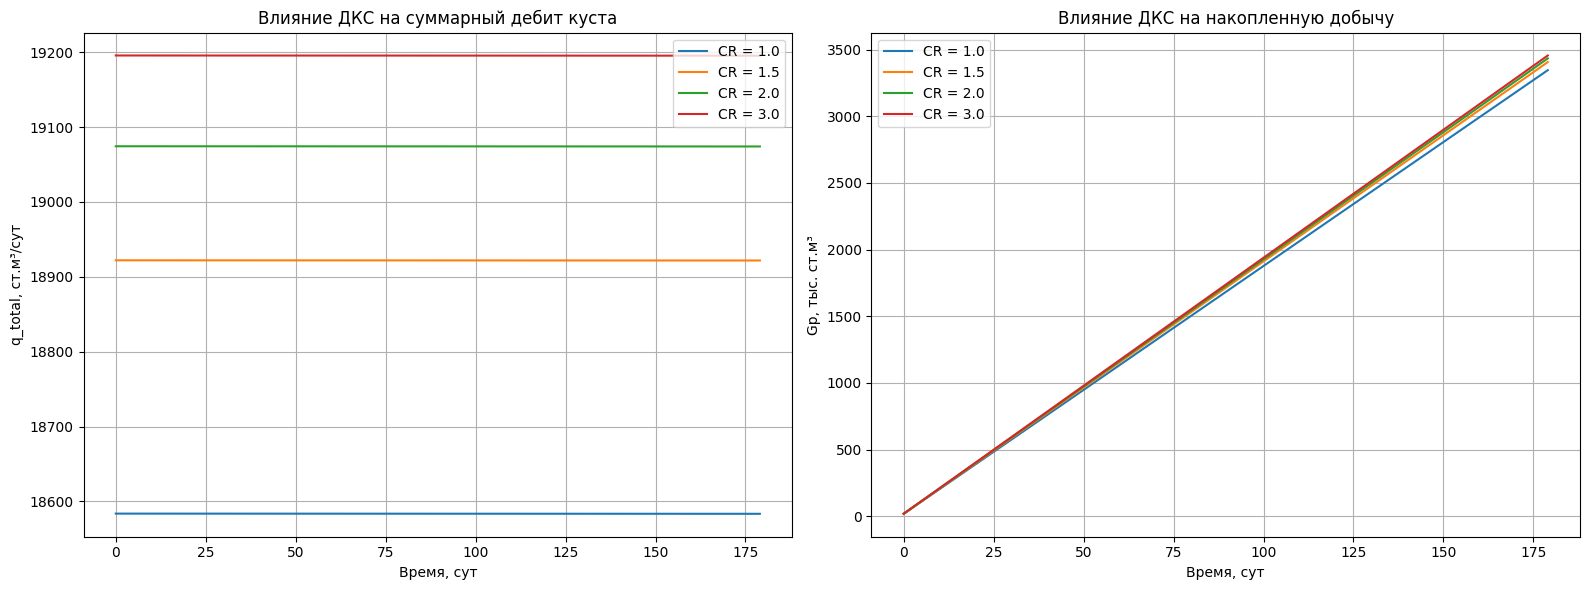

In [5]:
CR_list = [1.0, 1.5, 2.0, 3.0]
results_cr = {}

# Запускаем симулятор для каждого значения CR
for cr in CR_list:
    res_cr = Reservoir(ResProps(P=100.0, V=V_res, T=T_res), fluid)
    dcs_cr = DCS(CR=cr, P_line=5.0, q_ext=500.0)
    sim_cr = FieldSimulator(res_cr, [well1, well2, well3], shlyf, dcs_cr)
    
    # Для экономии вывода в консоль можно закомментировать print внутри simulator.py, 
    # но сейчас просто соберем данные
    results_cr[cr] = sim_cr.run(N_days=180, dt=1.0)

# Построение сравнительных графиков
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

for cr in CR_list:
    df_cr = results_cr[cr]
    axs[0].plot(df_cr['t'], df_cr['q_total'], label=f'CR = {cr}')
    axs[1].plot(df_cr['t'], df_cr['Gp'], label=f'CR = {cr}')

axs[0].set_title('Влияние ДКС на суммарный дебит куста')
axs[0].set_xlabel('Время, сут')
axs[0].set_ylabel('q_total, ст.м³/сут')
axs[0].grid(True)
axs[0].legend()

axs[1].set_title('Влияние ДКС на накопленную добычу')
axs[1].set_xlabel('Время, сут')
axs[1].set_ylabel('Gp, тыс. ст.м³')
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()

Калибровка завершена!
Оптимальный множитель проницаемости: 340.5235
Скорректированная проницаемость k: 17026.17 мД
RMSE: 2499.69 ст.м³/сут
R²: 0.9709


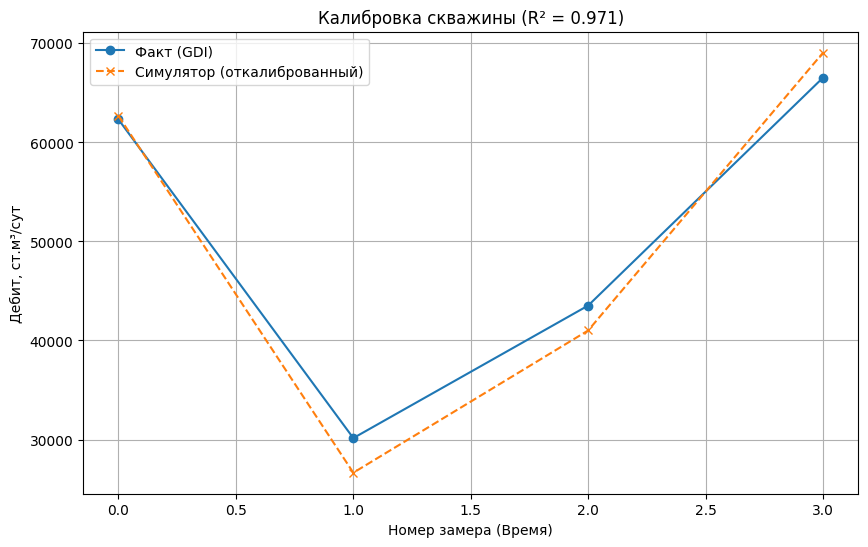

In [6]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

# Загрузка промысловых данных
try:
    df_fact = pd.read_csv('adapt_gdi_11-2025.csv')
    df_fact.columns = df_fact.columns.str.strip()
    
    # Извлекаем фактические данные (теперь строго с маленькой буквы, как в файле)
    q_fact = df_fact['q'].values
    P_res_fact = df_fact['p_res'].values
    P_bhp_fact = df_fact['p_bhp'].values
    
    # Создаем базовую скважину для калибровки (геометрия Скважины 1)
    well_calib = Well(fluid, k=50, h=25, re=500, rw=0.1, pipe=None)
    
    # Вспомогательная функция для расчета RMSE
    def calc_rmse(y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred)**2))
        
    # Вспомогательная функция для расчета R^2
    def calc_r2(y_true, y_pred):
        ss_res = np.sum((y_true - y_pred)**2)
        ss_tot = np.sum((y_true - np.mean(y_true))**2)
        if ss_tot == 0:
            return 0.0
        return 1.0 - (ss_res / ss_tot)
    
    # Целевая функция
    def objective_function(k_mult):
        well_calib.k = 50.0 * k_mult[0] # Меняем проницаемость (меняет C)
        
        q_sim = []
        for pr, pbhp in zip(P_res_fact, P_bhp_fact):
            q_sim.append(well_calib.q(pr, pbhp))
            
        return calc_rmse(q_fact, np.array(q_sim))

    # Оптимизация (Начальное приближение множителя = 1.0)
    res_opt = minimize(objective_function, x0=[1.0], bounds=[(0.01, 1000.0)], method='L-BFGS-B')
    best_mult = res_opt.x[0]
    
    # Расчет финальных метрик
    well_calib.k = 50.0 * best_mult
    q_sim_opt = np.array([well_calib.q(pr, pbhp) for pr, pbhp in zip(P_res_fact, P_bhp_fact)])
    
    final_rmse = calc_rmse(q_fact, q_sim_opt)
    final_r2 = calc_r2(q_fact, q_sim_opt)
    
    print(f"Калибровка завершена!")
    print(f"Оптимальный множитель проницаемости: {best_mult:.4f}")
    print(f"Скорректированная проницаемость k: {well_calib.k:.2f} мД")
    print(f"RMSE: {final_rmse:.2f} ст.м³/сут")
    print(f"R²: {final_r2:.4f}")
    
    # График Факт vs Модель
    plt.figure(figsize=(10, 6))
    plt.plot(q_fact, label='Факт (GDI)', marker='o', linestyle='-')
    plt.plot(q_sim_opt, label='Симулятор (откалиброванный)', marker='x', linestyle='--')
    plt.title(f'Калибровка скважины (R² = {final_r2:.3f})')
    plt.xlabel('Номер замера (Время)')
    plt.ylabel('Дебит, ст.м³/сут')
    plt.legend()
    plt.grid(True)
    plt.show()

except FileNotFoundError:
    print("Файл adapt_gdi_11-2025.csv не найден в корне проекта. Убедитесь, что он загружен.")
except Exception as e:
    print(f"Ошибка при обработке данных калибровки: {e}")